# TFT Feature Importance Analysis

This notebook analyzes the feature importance of trained TFT models by examining:
- Variable selection weights (which features are selected)
- Attention weights (which time steps are important)
- Temporal dynamics of feature importance

In [9]:
import os
import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from copy import deepcopy
import ipywidgets as widgets
from IPython.display import display
from sklearn.preprocessing import StandardScaler
import gc

# Import project utilities
from utils.models import get_model
from utils import preprocessing, tools

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✓ Imports successful')

✓ Imports successful


## 1. Model Selection

In [10]:
# List all available models
models_dir = Path('models')
model_files = sorted([f.name for f in models_dir.glob('*.pt') if f.is_file()])

print(f'Found {len(model_files)} models')
print(f'First 5: {model_files[:5]}')

Found 106 models
First 5: ['cl_m-tft_out-48_freq-1h_wind_00164.pt', 'cl_m-tft_out-48_freq-1h_wind_00183.pt', 'cl_m-tft_out-48_freq-1h_wind_00198.pt', 'cl_m-tft_out-48_freq-1h_wind_00232.pt', 'cl_m-tft_out-48_freq-1h_wind_00282.pt']


In [95]:
# Create selectbox for model selection
model_selector = widgets.Dropdown(
    options=model_files,
    description='Model:',
    disabled=False,
    style={'description_width': '100px'},
    layout=widgets.Layout(width='600px')
)

display(model_selector)

Dropdown(description='Model:', layout=Layout(width='600px'), options=('cl_m-tft_out-48_freq-1h_wind_00164.pt',…

## 2. Load Configuration

In [113]:
def get_config_path_from_model_name(model_name):
    """
    Extract config file path from model name.

    Example model names:
    - cl_m-tft_out-48_freq-1h_wind_50.pt -> config_wind_50.yaml
    - cl_m-tft_out-48_freq-1h_wind_00164.pt -> wind_100ex50/config_wind_00164.yaml
    - cl_m-tft_out-48_freq-1h_wind_50_nostatic.pt -> config_wind_50.yaml (special case)
    """
    # Extract the identifier part (e.g., 'wind_50', 'wind_00164', 'wind_50_nostatic')
    parts = model_name.replace('.pt', '').split('_')

    # Find the 'wind' part and everything after
    wind_idx = parts.index('wind')
    identifier = '_'.join(parts[wind_idx:])

    # Handle nostatic case: use base config (e.g., wind_50 from wind_50_nostatic)
    is_nostatic = 'nostatic' in identifier
    if is_nostatic:
        # Remove '_nostatic' suffix
        identifier = identifier.replace('_nostatic', '')

    # Determine config path
    # Short names like 'wind_50', 'wind_100' are in configs/
    # Numeric IDs like 'wind_00164' are in configs/wind_100ex50/
    numeric_id = parts[-1] if not is_nostatic else parts[-2]

    if numeric_id.isdigit() and len(numeric_id) == 5:
        # Numeric ID -> subdirectory
        if os.path.exists(f'configs/wind_100ex50/config_{identifier}.yaml'):
            config_path = Path(f'configs/wind_100ex50/config_{identifier}.yaml')
        else:
            config_path = Path(f'configs/wind_50/config_{identifier}.yaml')
    else:
        # Named config -> root configs directory
        config_path = Path(f'configs/config_{identifier}.yaml')

    return config_path, is_nostatic


def load_config(config_path, is_nostatic=False):
    """
    Load config from YAML file.
    If is_nostatic is True, set static_features to empty list.
    """
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    if is_nostatic:
        config['params']['static_features'] = []
        print('ℹ️  Nostatic model detected: static_features set to []')

    return config


# Test with selected model
selected_model = model_selector.value
config_path, is_nostatic = get_config_path_from_model_name(selected_model)

print(f'Selected model: {selected_model}')
print(f'Config path: {config_path}')
print(f'Is nostatic: {is_nostatic}')
print(f'Config exists: {config_path.exists()}')

Selected model: cl_m-tft_out-48_freq-1h_wind_00282.pt
Config path: configs/wind_50/config_wind_00282.yaml
Is nostatic: False
Config exists: True


In [114]:
# Load configuration
config = load_config(config_path, is_nostatic)

# Display key config parameters
print('\n=== Configuration Summary ===')
print(f"Known features ({len(config['params']['known_features'])}): {config['params']['known_features']}")
print(f"\nObserved features ({len(config['params']['observed_features'])}): {config['params']['observed_features']}")
print(f"\nStatic features ({len(config['params']['static_features'])}): {config['params']['static_features']}")
print(f"\nTest period: {config['data']['test_start']} to {config['data']['test_end']}")


=== Configuration Summary ===
Known features (4): ['wind_speed_h78', 'wind_speed_h127', 'wind_speed_h184', 'density_rotor_eq']

Observed features (1): ['power']

Static features (0): []

Test period: 2025-08-01 to 2025-10-31


## 3. Hyperparameter Optimization

In [115]:
# %% [markdown]
## 2.5. Load Hyperparameters from Optuna Study
# Load the best hyperparameters from the Optuna study that was used to train this model.

# %%
from utils import hpo

# Get study name from model name
# Model name format: cl_m-tft_out-48_freq-1h_wind_00164.pt
# Study name format: cl_m-tft_out-48_freq-1h_wind_00164
parts = selected_model.replace('.pt', '').split('_')
output_dim = int([p for p in parts if 'out-' in p][0].replace('out-', ''))
freq_part = [p for p in parts if 'freq-' in p][0]
freq = freq_part.replace('freq-', '')

# Build study name suffix (everything after freq)
freq_idx = parts.index(freq_part)
study_name_suffix = '_'.join(parts[freq_idx+1:])
config["model"]["name"] = 'tft'
study_name = f'cl_m-{config["model"]["name"]}_out-{output_dim}_freq-{freq}_{study_name_suffix}'

print(f'Study name: {study_name}')
print(f'Studies path: {config["hpo"]["studies_path"]}')

# Load study and get hyperparameters
study = None
if config['model']['lookup_hpo']:
    print('\nLoading Optuna study...')
    study = hpo.load_study(config['hpo']['studies_path'], study_name)
    print(f'✓ Study loaded: {study.study_name}')
    print(f'  Best trial: {study.best_trial.number}')
    print(f'  Best value: {study.best_value:.4f}')

hyperparameters = hpo.get_hyperparameters(config=config, study=study)

print('\n=== Hyperparameters Summary ===')
for key, value in hyperparameters.items():
    if isinstance(value, dict):
        print(f'{key}:')
        for k, v in value.items():
            print(f'  {k}: {v}')
    else:
        print(f'{key}: {value}')

Study name: cl_m-tft_out-48_freq-1h_wind_00282
Studies path: /mnt/nvme1/optuna_studies/optuna_viktor.db

Loading Optuna study...
✓ Study loaded: cl_m-tft_out-48_freq-1h_wind_00282
  Best trial: 67
  Best value: 0.0366

=== Hyperparameters Summary ===
shuffle: True
batch_size: 210
lr: 0.00023027007443177398
n_heads: 8
hidden_dim: 96
dropout: 0.5418621401009314
num_lstm_layers: 1
static_embedding_dim: 128
clipnorm: 7.208800680226671
lookback: 48
horizon: 48


## 4. Load and Prepare Data

**Important:** Data preparation must happen BEFORE model creation, because the feature dimensions are extracted from the prepared data.

In [116]:
# Set model name in config
config['model']['name'] = 'tft'

# Get features
features = preprocessing.get_features(config=config)
print(f'Features: {features}')

# Load data
print('\nLoading data...')
data_dir = config['data']['path']
freq = config['data']['freq']

dfs = preprocessing.get_data(
    data_dir=data_dir,
    config=config,
    freq=freq,
    features=features
)
print(f'Loaded {len(dfs)} dataframes')
print(f'Keys: {list(dfs.keys())[:5]}...')

Features: {'known': ['wind_speed_h78', 'wind_speed_h127', 'wind_speed_h184', 'density_rotor_eq'], 'observed': ['power'], 'static': []}

Loading data...
Loaded 1 dataframes
Keys: ['synth_00282.csv']...


In [117]:
# Fit global scaler (same as in train_cl.py)
print('Fitting global scaler...')
global_scaler_x = StandardScaler()

target_col = config['data']['target_col']
test_start = pd.Timestamp(config['data']['test_start'], tz='UTC')
test_end = pd.Timestamp(config['data']['test_end'], tz='UTC')

# If test_end is at 00:00, extend to include the whole day
if test_end.hour == 0 and test_end.minute == 0 and test_end.second == 0:
    test_end = test_end.replace(hour=23, minute=0, second=0)

for key, df in dfs.items():
    df_temp = df.copy()

    # Drop target column
    if target_col in df_temp.columns:
        df_temp.drop(target_col, axis=1, inplace=True)

    t_0 = 0 if config['eval']['eval_on_all_test_data'] else config['eval']['t_0']
    df_train, _ = preprocessing.split_data(
        data=df_temp,
        train_frac=config['data']['train_frac'],
        test_start=test_start,
        test_end=test_end,
        t_0=t_0
    )
    global_scaler_x.partial_fit(df_train)

    del df_temp, df_train
    gc.collect()

print('✓ Global scaler fitted')

Fitting global scaler...
✓ Global scaler fitted


In [118]:
# Prepare data for TFT (this extracts feature_dim automatically)
print('Preparing data for TFT...')

data_generator = tools.create_data_generator(dfs, config, features, scaler_x=global_scaler_x)
X_train, y_train, X_test, y_test, test_data = tools.combine_datasets_efficiently(data_generator)

print('\n=== Prepared Data Summary ===')
if isinstance(X_train, dict):
    if 'known' in X_train:
        print(f'X_train known: {X_train["known"].shape}, X_test known: {X_test["known"].shape}')
    if 'static' in X_train:
        print(f'X_train static: {X_train["static"].shape}, X_test static: {X_test["static"].shape}')
    print(f'X_train observed: {X_train["observed"].shape}, X_test observed: {X_test["observed"].shape}')
    print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')
else:
    print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
    print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')

# Extract feature dimensions from prepared data
feature_dims = {}
if isinstance(X_train, dict):
    feature_dims['observed_dim'] = X_train['observed'].shape[-1]
    feature_dims['known_dim'] = X_train['known'].shape[-1] if 'known' in X_train else 0
    feature_dims['static_dim'] = X_train['static'].shape[-1] if 'static' in X_train else 0
else:
    feature_dims['observed_dim'] = X_train.shape[-1]
    feature_dims['known_dim'] = 0
    feature_dims['static_dim'] = 0

config['model']['feature_dim'] = feature_dims

print(f'\nFeature dimensions: {feature_dims}')

gc.collect()

Preparing data for TFT...

=== Prepared Data Summary ===
X_train known: (2917, 96, 4), X_test known: (364, 96, 4)
X_train observed: (2917, 48, 1), X_test observed: (364, 48, 1)
y_train: (2917, 48), y_test: (364, 48)

Feature dimensions: {'observed_dim': 1, 'known_dim': 4, 'static_dim': 0}


0

## 5. Load Model

Now that we have the feature dimensions, we can create and load the model.

In [119]:
# Load the trained model checkpoint
model_path = models_dir / selected_model
checkpoint = torch.load(model_path, map_location='cpu')

print('Checkpoint keys:', list(checkpoint.keys())[:5])

# Extract state dict
if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
elif 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

# 🔧 FIX: Remove '_orig_mod.' prefix from keys (added by torch.compile)
cleaned_state_dict = {}
for key, value in state_dict.items():
    if key.startswith('_orig_mod.'):
        cleaned_state_dict[key.replace('_orig_mod.', '')] = value
    else:
        cleaned_state_dict[key] = value

print(f'Cleaned state dict keys. Sample: {list(cleaned_state_dict.keys())[:5]}')

Checkpoint keys: ['_orig_mod.observed_embed.0.weight', '_orig_mod.observed_embed.0.bias', '_orig_mod.known_embed.0.weight', '_orig_mod.known_embed.0.bias', '_orig_mod.known_embed.1.weight']
Cleaned state dict keys. Sample: ['observed_embed.0.weight', 'observed_embed.0.bias', 'known_embed.0.weight', 'known_embed.0.bias', 'known_embed.1.weight']


In [120]:
# Create model instance with correct dimensions
#hyperparameters = config['model'].copy()
hyperparameters['model_type'] = 'tft'

# Add feature dimensions to hyperparameters
hyperparameters.update(feature_dims)

print('Hyperparameters for model creation:')
print(f"  observed_dim: {hyperparameters['observed_dim']}")
print(f"  known_dim: {hyperparameters['known_dim']}")
print(f"  static_dim: {hyperparameters['static_dim']}")
print(f"  hidden_dim: {hyperparameters['hidden_dim']}")
print(f"  n_heads: {hyperparameters['n_heads']}")

# Create model instance
model = get_model(config, hyperparameters)

# Load weights
model.load_state_dict(cleaned_state_dict)
model.eval()

print('\n✓ Model loaded successfully')

Hyperparameters for model creation:
  observed_dim: 1
  known_dim: 4
  static_dim: 0
  hidden_dim: 96
  n_heads: 8

✓ Model loaded successfully


## 6. Run Inference and Extract Attention Weights

In [121]:
# Extract test data tensors
test_observed = X_test['observed'] if isinstance(X_test, dict) else X_test
test_known = X_test.get('known', None) if isinstance(X_test, dict) else None
test_static = X_test.get('static', None) if isinstance(X_test, dict) else None

print(f'Test observed shape: {test_observed.shape}')
if test_known is not None:
    print(f'Test known shape: {test_known.shape}')
if test_static is not None:
    print(f'Test static shape: {test_static.shape}')

# Convert to torch tensors if needed
if not isinstance(test_observed, torch.Tensor):
    test_observed = torch.FloatTensor(test_observed)
if test_known is not None and not isinstance(test_known, torch.Tensor):
    test_known = torch.FloatTensor(test_known)
if test_static is not None and not isinstance(test_static, torch.Tensor):
    test_static = torch.FloatTensor(test_static)

Test observed shape: (364, 48, 1)
Test known shape: (364, 96, 4)


In [122]:
# Run inference with attention weights extraction
print('Running inference on test set...')

with torch.no_grad():
    # Forward pass with attention weight extraction
    if test_static is not None:
        predictions, attention_dict = model(
            test_observed,
            test_known,
            test_static,
            return_attention_weights=True
        )
    else:
        predictions, attention_dict = model(
            test_observed,
            test_known,
            return_attention_weights=True
        )

print(f'Predictions shape: {predictions.shape}')
print(f'\nAttention weights available:')
for key, value in attention_dict.items():
    if isinstance(value, torch.Tensor):
        print(f'  {key}: {value.shape}')
    else:
        print(f'  {key}: {type(value)}')

Running inference on test set...
Predictions shape: torch.Size([364, 48])

Attention weights available:
  decoder_self_attn: torch.Size([8, 364, 96, 96])
  static_weights: <class 'NoneType'>
  past_weights: torch.Size([364, 48, 5])
  future_weights: torch.Size([364, 48, 4])


## 7. Analyze Variable Selection Weights

In [123]:
# Extract variable selection weights
# These indicate which features are selected at each time step

# Static features variable selection
if 'static_weights' in attention_dict and attention_dict['static_weights'] is not None:
    static_weights = attention_dict['static_weights'].cpu().numpy()
    print(f'Static variable selection weights shape: {static_weights.shape}')

    # Average over all samples and time
    avg_static_weights = static_weights.mean(axis=(0, 1)) if static_weights.ndim > 2 else static_weights.mean(axis=0)

    # Plot static feature importance
    fig, ax = plt.subplots(figsize=(10, 6))
    static_features = config['params']['static_features']

    bars = ax.barh(static_features, avg_static_weights)
    ax.set_xlabel('Average Selection Weight', fontsize=12)
    ax.set_title('Static Feature Importance (Variable Selection Weights)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Color bars by importance
    colors = plt.cm.viridis(avg_static_weights / avg_static_weights.max())
    for bar, color in zip(bars, colors):
        bar.set_color(color)

    plt.tight_layout()
    plt.show()

    # Print sorted feature importance
    feature_importance_df = pd.DataFrame({
        'Feature': static_features,
        'Importance': avg_static_weights
    }).sort_values('Importance', ascending=False)

    print('\nStatic Feature Importance (sorted):')
    print(feature_importance_df.to_string(index=False))
else:
    print('No static features in this model')

No static features in this model


Past variable selection weights shape: (364, 48, 5)


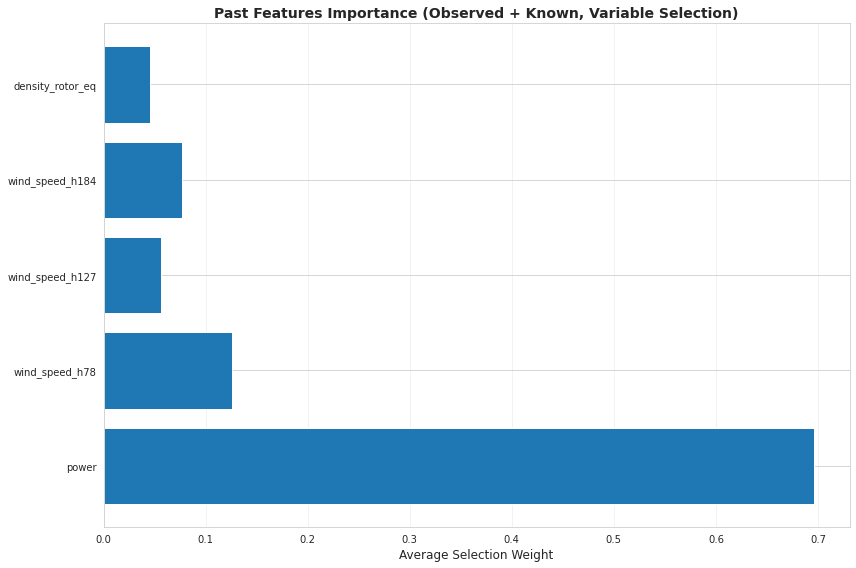


Past Features Importance (sorted):
         Feature  Importance
           power    0.696206
  wind_speed_h78    0.125949
 wind_speed_h184    0.076801
 wind_speed_h127    0.055811
density_rotor_eq    0.045235


In [124]:
# Past (observed + known) features variable selection
if 'past_weights' in attention_dict:
    past_weights = attention_dict['past_weights'].cpu().numpy()
    print(f'Past variable selection weights shape: {past_weights.shape}')
    # Shape: (batch, time, num_features)

    # Average over samples and time
    avg_past_weights = past_weights.mean(axis=(0, 1))

    # Feature names: observed + known
    past_features = config['params']['observed_features'] + config['params']['known_features']

    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(past_features, avg_past_weights)
    ax.set_xlabel('Average Selection Weight', fontsize=12)
    ax.set_title('Past Features Importance (Observed + Known, Variable Selection)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # colors = plt.cm.plasma(avg_past_weights / avg_past_weights.max())
    # for bar, color in zip(bars, colors):
    #     bar.set_color(color)

    plt.tight_layout()
    plt.show()

    # Print sorted
    feature_importance_df = pd.DataFrame({
        'Feature': past_features,
        'Importance': avg_past_weights
    }).sort_values('Importance', ascending=False)

    print('\nPast Features Importance (sorted):')
    print(feature_importance_df.to_string(index=False))
else:
    print('No past variable selection weights found')

Future variable selection weights shape: (364, 48, 4)


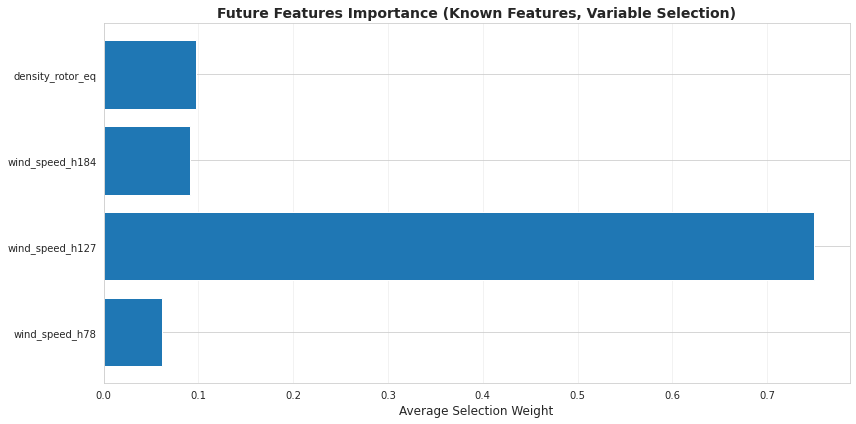


Future Features Importance (sorted):
         Feature  Importance
 wind_speed_h127    0.749369
density_rotor_eq    0.097382
 wind_speed_h184    0.091548
  wind_speed_h78    0.061702


In [125]:
# Future (known only) features variable selection
if 'future_weights' in attention_dict:
    future_weights = attention_dict['future_weights'].cpu().numpy()
    print(f'Future variable selection weights shape: {future_weights.shape}')
    # Shape: (batch, time, num_features)

    # Average over samples and time
    avg_future_weights = future_weights.mean(axis=(0, 1))

    # Feature names: known only
    future_features = config['params']['known_features']

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(future_features, avg_future_weights)
    ax.set_xlabel('Average Selection Weight', fontsize=12)
    ax.set_title('Future Features Importance (Known Features, Variable Selection)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # colors = plt.cm.cividis(avg_future_weights / avg_future_weights.max())
    # for bar, color in zip(bars, colors):
    #     bar.set_color(color)

    plt.tight_layout()
    plt.show()

    # Print sorted
    feature_importance_df = pd.DataFrame({
        'Feature': future_features,
        'Importance': avg_future_weights
    }).sort_values('Importance', ascending=False)

    print('\nFuture Features Importance (sorted):')
    print(feature_importance_df.to_string(index=False))
else:
    print('No future variable selection weights found')

## 8. Analyze Temporal Attention Weights

Temporal attention weights shape: (8, 364, 96, 96)
Average attention shape: (96, 96)


/tmp/ipykernel_3123261/4294169531.py:21: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(im, ax=ax)


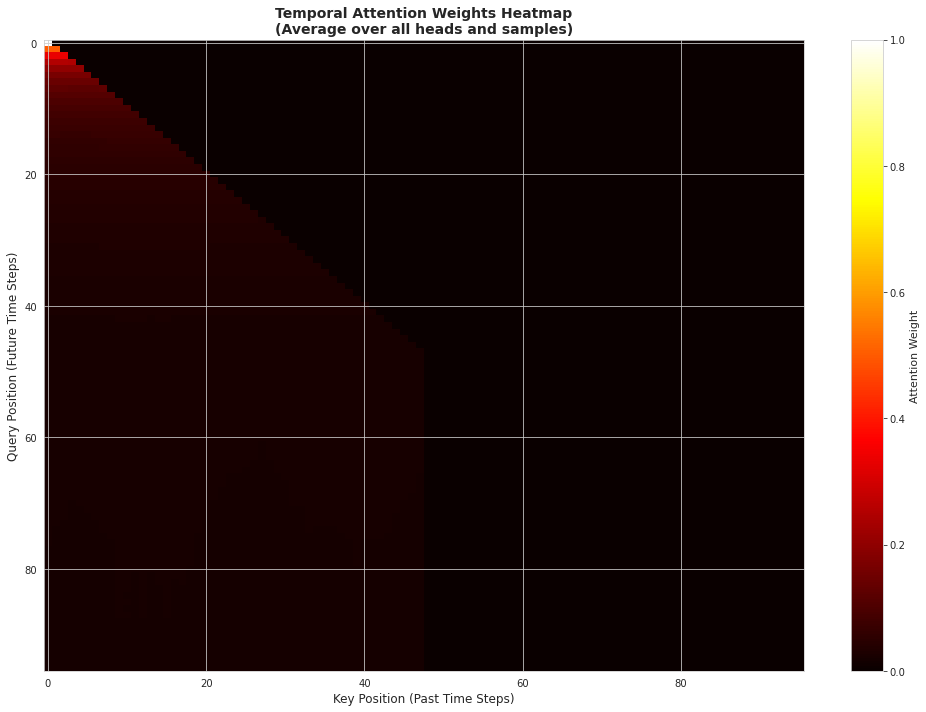

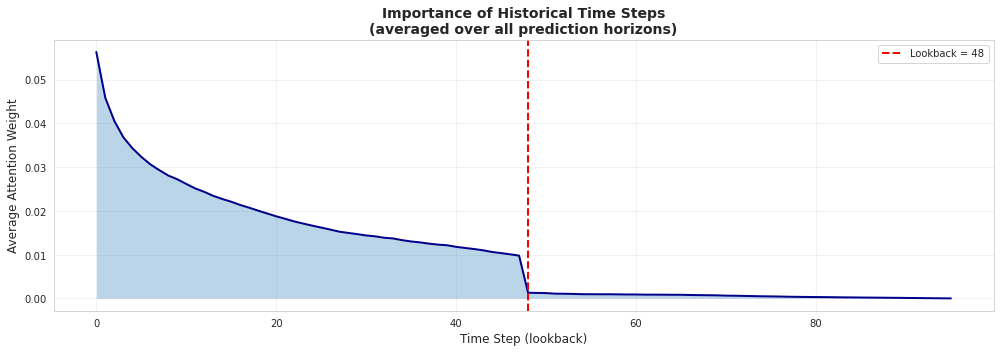


Top 10 most important time steps (lookback positions):
1. Position 0: 0.0563
2. Position 1: 0.0459
3. Position 2: 0.0406
4. Position 3: 0.0369
5. Position 4: 0.0344
6. Position 5: 0.0324
7. Position 6: 0.0307
8. Position 7: 0.0293
9. Position 8: 0.0281
10. Position 9: 0.0272


In [126]:
# Temporal attention shows which time steps are important
if 'decoder_self_attn' in attention_dict:
    temporal_attention = attention_dict['decoder_self_attn'].cpu().numpy()
    print(f'Temporal attention weights shape: {temporal_attention.shape}')
    # Shape typically: (n_heads, batch, time_q, time_k)

    # Average over heads and batch dimension
    avg_attention = temporal_attention.mean(axis=(0, 1)) if temporal_attention.ndim == 4 else temporal_attention.mean(axis=0)

    print(f'Average attention shape: {avg_attention.shape}')

    # Plot attention heatmap
    fig, ax = plt.subplots(figsize=(14, 10))

    im = ax.imshow(avg_attention, cmap='hot', aspect='auto', interpolation='nearest')
    ax.set_xlabel('Key Position (Past Time Steps)', fontsize=12)
    ax.set_ylabel('Query Position (Future Time Steps)', fontsize=12)
    ax.set_title('Temporal Attention Weights Heatmap\n(Average over all heads and samples)',
                 fontsize=14, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Attention Weight', fontsize=11)

    plt.tight_layout()
    plt.show()

    # Plot average attention per time step
    avg_attention_per_step = avg_attention.mean(axis=0)  # Average over queries

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(avg_attention_per_step, linewidth=2, color='darkblue')
    ax.fill_between(range(len(avg_attention_per_step)), avg_attention_per_step, alpha=0.3)
    ax.set_xlabel('Time Step (lookback)', fontsize=12)
    ax.set_ylabel('Average Attention Weight', fontsize=12)
    ax.set_title('Importance of Historical Time Steps\n(averaged over all prediction horizons)',
                 fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)

    # Mark lookback boundary
    lookback = config['model']['lookback']
    if lookback < len(avg_attention_per_step):
        ax.axvline(lookback, color='red', linestyle='--', linewidth=2, label=f'Lookback = {lookback}')
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Find most important time steps
    top_k = 10
    top_indices = np.argsort(avg_attention_per_step)[-top_k:][::-1]

    print(f'\nTop {top_k} most important time steps (lookback positions):')
    for i, idx in enumerate(top_indices, 1):
        print(f'{i}. Position {idx}: {avg_attention_per_step[idx]:.4f}')
else:
    print('No temporal attention weights found')

## 9. Temporal Evolution of Variable Selection

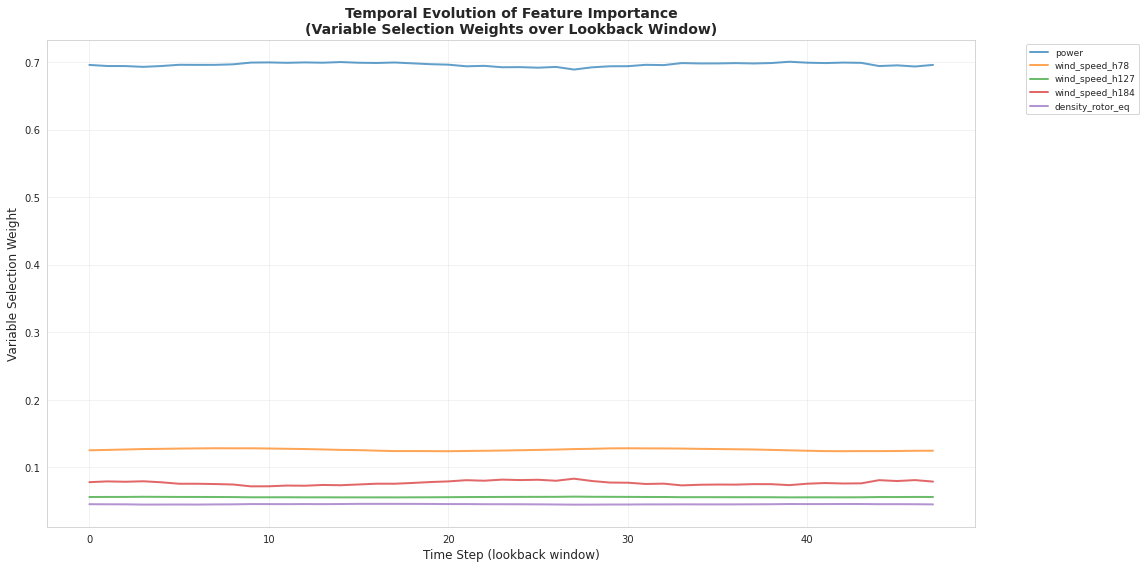

/tmp/ipykernel_3123261/2996851365.py:38: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(im, ax=ax)


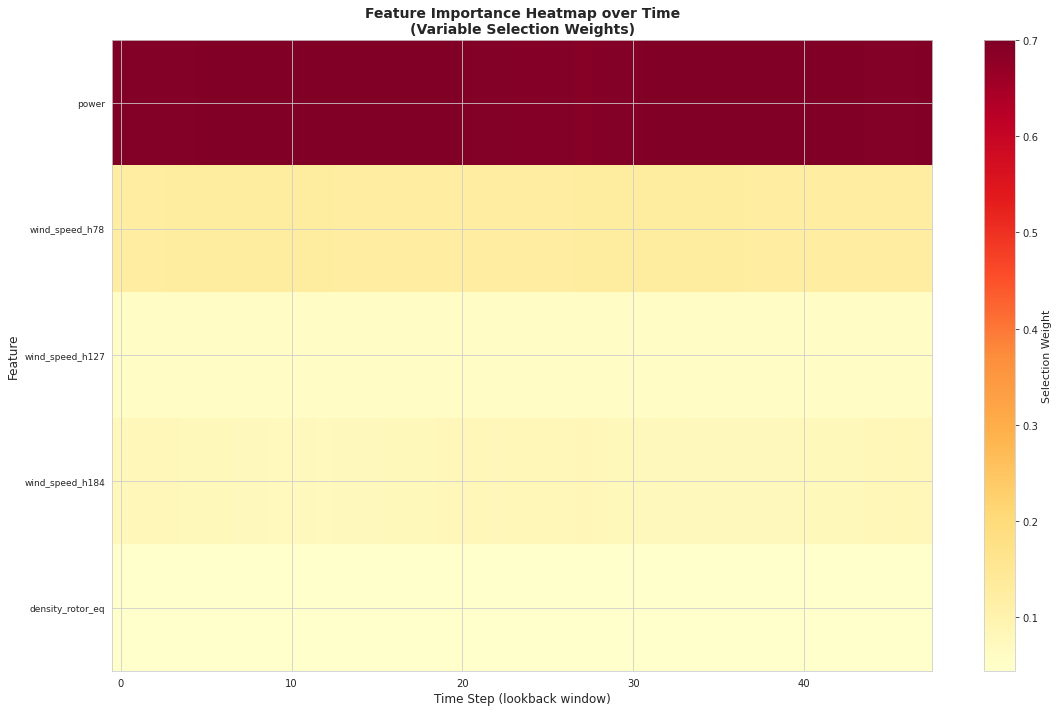

In [127]:
# Analyze how feature importance changes over time during the lookback window
if 'past_weights' in attention_dict:
    past_weights = attention_dict['past_weights'].cpu().numpy()
    # Shape: (batch, time, num_features)

    # Average over batch dimension
    avg_over_batch = past_weights.mean(axis=0)  # (time, num_features)

    past_features = config['params']['observed_features'] + config['params']['known_features']

    # Plot temporal evolution
    fig, ax = plt.subplots(figsize=(16, 8))

    for i, feature in enumerate(past_features):
        ax.plot(avg_over_batch[:, i], label=feature, linewidth=2, alpha=0.7)

    ax.set_xlabel('Time Step (lookback window)', fontsize=12)
    ax.set_ylabel('Variable Selection Weight', fontsize=12)
    ax.set_title('Temporal Evolution of Feature Importance\n(Variable Selection Weights over Lookback Window)',
                 fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Heatmap version
    fig, ax = plt.subplots(figsize=(16, 10))

    im = ax.imshow(avg_over_batch.T, cmap='YlOrRd', aspect='auto', interpolation='nearest')
    ax.set_xlabel('Time Step (lookback window)', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_yticks(range(len(past_features)))
    ax.set_yticklabels(past_features, fontsize=9)
    ax.set_title('Feature Importance Heatmap over Time\n(Variable Selection Weights)',
                 fontsize=14, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Selection Weight', fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print('No temporal variable selection data available')

## 10. Summary Statistics

In [128]:
# Create summary table of all feature importance scores
summary_data = []

# Static features
if 'static_weights' in attention_dict and attention_dict['static_weights'] is not None:
    static_weights = attention_dict['static_weights'].cpu().numpy()
    avg_static_weights = static_weights.mean(axis=(0, 1)) if static_weights.ndim > 2 else static_weights.mean(axis=0)

    for feat, weight in zip(config['params']['static_features'], avg_static_weights):
        summary_data.append({
            'Feature Type': 'Static',
            'Feature Name': feat,
            'Avg Weight': weight,
            'Std Weight': static_weights.std()
        })

# Past features
if 'past_weights' in attention_dict:
    past_weights = attention_dict['past_weights'].cpu().numpy()
    avg_past_weights = past_weights.mean(axis=(0, 1))
    std_past_weights = past_weights.std(axis=(0, 1))

    past_features = config['params']['observed_features'] + config['params']['known_features']

    for i, feat in enumerate(past_features):
        feat_type = 'Observed' if feat in config['params']['observed_features'] else 'Known (Past)'
        summary_data.append({
            'Feature Type': feat_type,
            'Feature Name': feat,
            'Avg Weight': avg_past_weights[i],
            'Std Weight': std_past_weights[i]
        })

# Future features
if 'future_weights' in attention_dict:
    future_weights = attention_dict['future_weights'].cpu().numpy()
    avg_future_weights = future_weights.mean(axis=(0, 1))
    std_future_weights = future_weights.std(axis=(0, 1))

    for i, feat in enumerate(config['params']['known_features']):
        summary_data.append({
            'Feature Type': 'Known (Future)',
            'Feature Name': feat,
            'Avg Weight': avg_future_weights[i],
            'Std Weight': std_future_weights[i]
        })

# Create DataFrame
summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Avg Weight', ascending=False).reset_index(drop=True)

print('\n=== Feature Importance Summary ===')
print(summary_df.to_string(index=False))

# Save to CSV
os.makedirs('feature_importance', exist_ok=True)
output_path = f'feature_importances/feature_importance_{selected_model.replace(".pt", "")}.csv'
summary_df.to_csv(output_path, index=False)
print(f'\n✓ Summary saved to: {output_path}')


=== Feature Importance Summary ===
  Feature Type     Feature Name  Avg Weight  Std Weight
Known (Future)  wind_speed_h127    0.749369    0.027638
      Observed            power    0.696206    0.055316
  Known (Past)   wind_speed_h78    0.125949    0.009855
Known (Future) density_rotor_eq    0.097382    0.039971
Known (Future)  wind_speed_h184    0.091548    0.023674
  Known (Past)  wind_speed_h184    0.076801    0.057620
Known (Future)   wind_speed_h78    0.061702    0.003734
  Known (Past)  wind_speed_h127    0.055811    0.004894
  Known (Past) density_rotor_eq    0.045235    0.007365


OSError: Cannot save file into a non-existent directory: 'feature_importances'

## 11. Export Attention Weights

In [ ]:
# Save all attention weights for further analysis
import pickle

output_dict = {
    'model_name': selected_model,
    'config_path': str(config_path),
    'attention_weights': {},
    'predictions': predictions.cpu().numpy(),
    'feature_names': {
        'static': config['params']['static_features'],
        'observed': config['params']['observed_features'],
        'known': config['params']['known_features']
    }
}

# Convert tensors to numpy
for key, value in attention_dict.items():
    if value is not None:
        if isinstance(value, torch.Tensor):
            output_dict['attention_weights'][key] = value.cpu().numpy()
        else:
            output_dict['attention_weights'][key] = value

# Save to pickle
pickle_path = f'attention_weights_{selected_model.replace(".pt", "")}.pkl'
# with open(pickle_path, 'wb') as f:
#     pickle.dump(output_dict, f)

print(f'✓ Attention weights saved to: {pickle_path}')
print(f'  Keys: {list(output_dict["attention_weights"].keys())}')